<a href="https://colab.research.google.com/github/KrzysztofDrobnik/lecture1/blob/regresja/PUM5_klasyfikacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
y = data.target
X = data.data

In [ ]:
print(X.shape[0])
print(X.shape[1])

569
30


In [ ]:
list(data.target_names)

[np.str_('malignant'), np.str_('benign')]

In [ ]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [ ]:
import pandas as pd
data = load_breast_cancer()
df = pd.DataFrame(data = X, columns=data.feature_names)
df['target'] = y

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df[df['target'] == 1].shape[0]

357

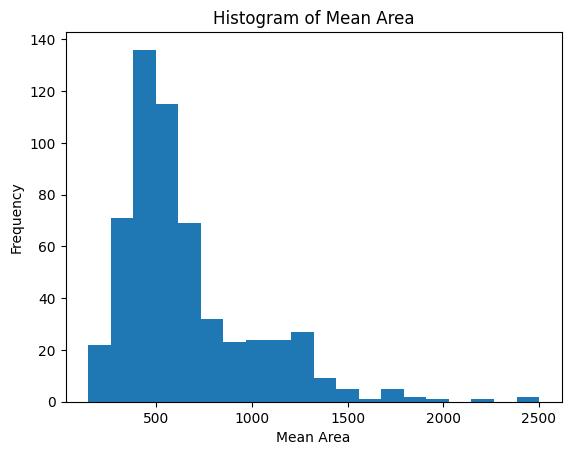

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['mean area'], bins=20)
plt.xlabel('Mean Area')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Area')
plt.show()

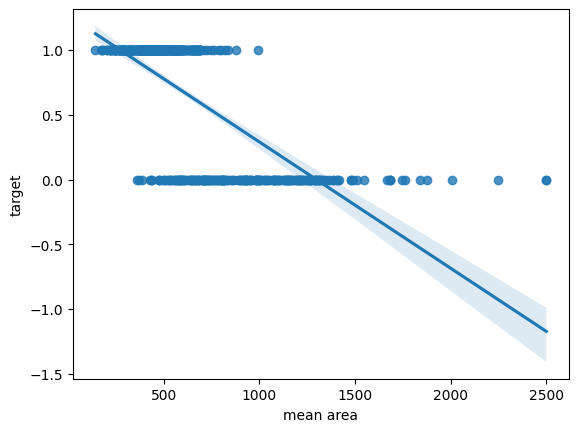

In [ ]:
import seaborn as sns
sns.regplot(x='mean area', y='target', data=df)

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = LogisticRegression()
reg.fit(X_train, y_train)

LogisticRegression()

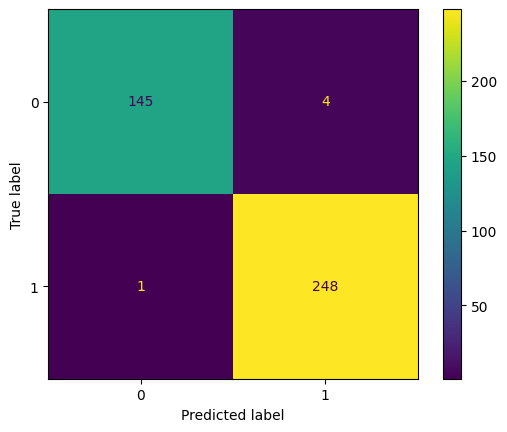

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
cm_train = confusion_matrix(y_train, reg.predict(X_train))
ConfusionMatrixDisplay(cm_train, display_labels=reg.classes_).plot()

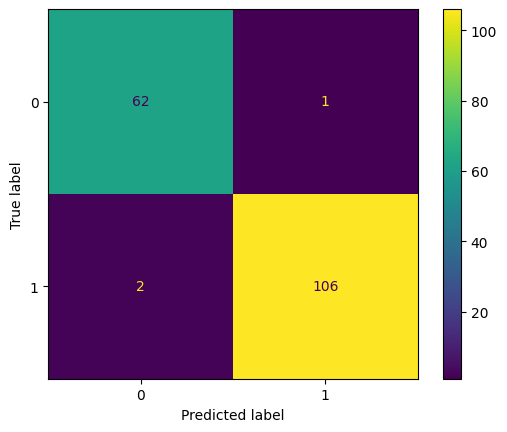

In [ ]:


cm = confusion_matrix(y_test, reg.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=reg.classes_).plot()


In [ ]:
cr = classification_report(y_test, reg.predict(X_test))

print(cr)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


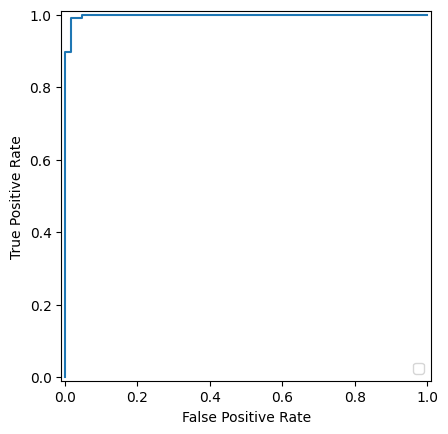

In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_curve
y_score = reg.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=reg.classes_[1])
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()